In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
rng = np.random.default_rng(seed=42)

### Solution 1

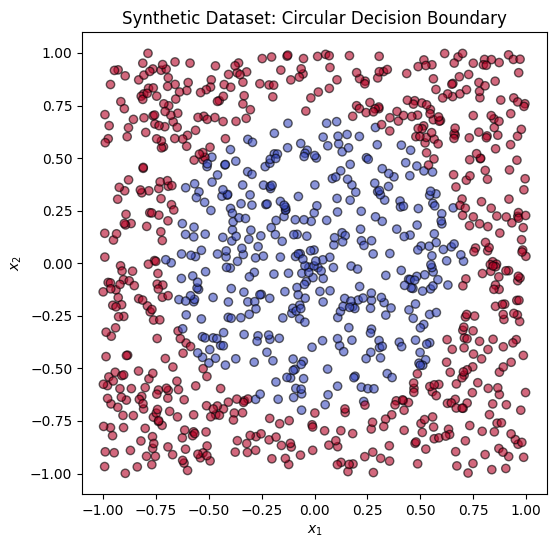

In [ ]:
N = 1000
X = rng.uniform(-1, 1, size=(N, 2))
# Rule: y=1 if distance from origin > sqrt(0.5) approx 0.707
y = (np.sum(X**2, axis=1) > 0.5).astype(int).reshape(-1, 1)

# Split 80/20
split = int(0.8 * N)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

def plot_dataset():
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.6)
    plt.title("Synthetic Dataset: Circular Decision Boundary")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.show()

plot_dataset() 

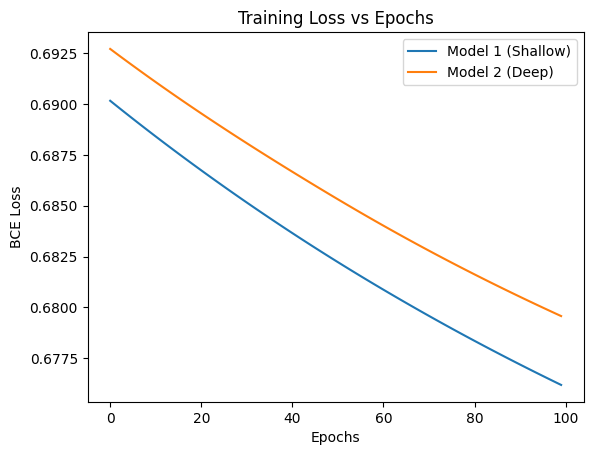

Model 1 Accuracy: 0.6100, Confusion Matrix 1: [[  0  78]
 [  0 122]]
Model 2 Accuracy: 0.6100, Confusion Matrix 2: [[  0  78]
 [  0 122]]


In [2]:
class NeuralNetwork:
    def __init__(self, layers):
        self.weights = []
        self.biases = []
        for i in range(len(layers) - 1):
            # Normal initialization N(0, 0.1)
            self.weights.append(rng.normal(0, 0.1, (layers[i], layers[i+1])))
            self.biases.append(np.zeros((1, layers[i+1])))

    def relu(self, z): return np.maximum(0, z)
    def relu_deriv(self, z): return (z > 0).astype(float)
    def sigmoid(self, z): return 1 / (1 + np.exp(-z))
    
    def forward(self, X):
        self.activations = [X]
        self.zs = []
        
        curr = X
        for i in range(len(self.weights) - 1):
            z = curr @ self.weights[i] + self.biases[i]
            self.zs.append(z)
            curr = self.relu(z)
            self.activations.append(curr)
            
        # Output layer
        z_final = curr @ self.weights[-1] + self.biases[-1]
        self.zs.append(z_final)
        self.activations.append(self.sigmoid(z_final))
        return self.activations[-1]

    def backward(self, y, learning_rate):
        m = y.shape[0]
        y_hat = self.activations[-1]
        
        # dL/dz for output layer (Binary Cross Entropy + Sigmoid shortcut)
        delta = (y_hat - y) 
        
        for i in reversed(range(len(self.weights))):
            dW = (self.activations[i].T @ delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m
            
            if i > 0:
                # Backpropagate delta to previous layer
                delta = (delta @ self.weights[i].T) * self.relu_deriv(self.zs[i-1])
            
            # Update
            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * db

def train_model(layers, X, y, epochs=100, lr=0.01):
    nn = NeuralNetwork(layers)
    losses = []
    for _ in range(epochs):
        y_prob = nn.forward(X)
        # Loss calculation
        loss = -np.mean(y * np.log(y_prob + 1e-8) + (1 - y) * np.log(1 - y_prob + 1e-8))
        losses.append(loss)
        nn.backward(y, lr)
    return nn, losses

# Training
model1, loss1 = train_model([2, 20, 1], X_train, y_train)
model2, loss2 = train_model([2, 10, 10, 1], X_train, y_train)

# --- (c) Plotting Loss ---
plt.plot(loss1, label='Model 1 (Shallow)')
plt.plot(loss2, label='Model 2 (Deep)')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend()
plt.title('Training Loss vs Epochs')
plt.show()

# --- (d) Evaluation ---
def evaluate(model, X, y):
    probs = model.forward(X)
    preds = (probs >= 0.5).astype(int)
    acc = np.mean(preds == y)
    
    # Simple Confusion Matrix
    tp = np.sum((preds == 1) & (y == 1))
    tn = np.sum((preds == 0) & (y == 0))
    fp = np.sum((preds == 1) & (y == 0))
    fn = np.sum((preds == 0) & (y == 1))
    cm = np.array([[tn, fp], [fn, tp]])
    return acc, cm

acc1, cm1 = evaluate(model1, X_test, y_test)
acc2, cm2 = evaluate(model2, X_test, y_test)

print(f"Model 1 Accuracy: {acc1:.4f}, Confusion Matrix 1: {cm1}")
print(f"Model 2 Accuracy: {acc2:.4f}, Confusion Matrix 2: {cm2}")

### Solution 3 (part 4)

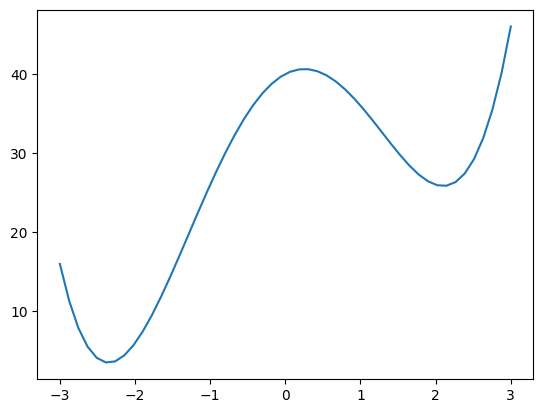

In [ ]:
w = np.linspace(-3, 3)
L = w**4 - 10* w**2 + 5*w + 40
plt.plot(w, L)
plt.show()

### Solution 4

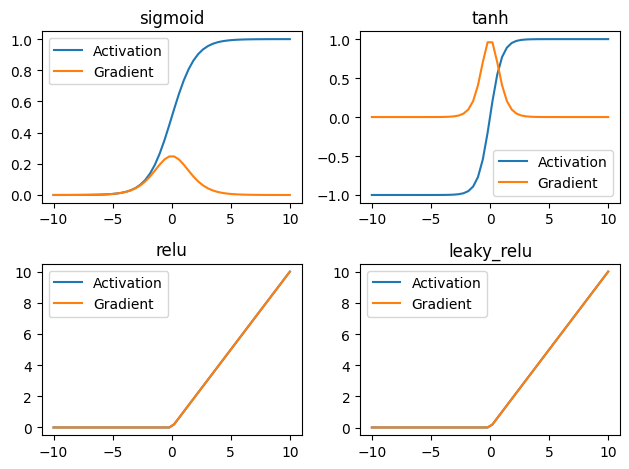

In [ ]:
class Activation:
    sigmoid = {
        'activation': lambda z: 1 / (1 + np.exp(-z)),
        'gradient': lambda ypred: ypred * (1 - ypred)
    }
    tanh = {
        'activation': lambda z: (1 - np.exp(-2*z)) / (1 + np.exp(-2*z)),
        'gradient': lambda ypred: 1 - y**2
    }
    relu = {
        'activation': lambda z: np.where(z > 0, z, 0),
        'gradient': lambda ypred: np.where(ypred > 0, ypred, 0)
    }
    leaky_relu = {
        'activation': lambda z: np.where(z > 0, z, 0.01),
        'gradient': lambda ypred: np.where(ypred > 0, ypred, 0.01)
    }

z = np.linspace(-10, 10)
activations = [['sigmoid', 'tanh'], ['relu', 'leaky_relu']]
fig, axes = plt.subplots(nrows=2, ncols=2)
for i, row in enumerate(activations):
    for j, name in enumerate(row):
        activation = getattr(Activation, name)
        y = activation['activation'](z)
        grad = activation['gradient'](y)
        ax = axes[i][j]
        ax.plot(z, y, label='Activation')
        ax.plot(z, grad, label='Gradient')
        ax.set_title(name)
        ax.legend()
fig.tight_layout()


### Solution 7

In [ ]:
def xavier_init(fin, fout):
    limit = np.sqrt(6 / (fin + fout))
    return rng.uniform(-limit, limit, size=(fout, fin))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Dataset
X = rng.uniform(-1, 1, size=(20, 2)) 
y_true = np.expand_dims(X[:, 0]**2 + X[:, 1]**2, axis=1)

# Parameters
W1 = xavier_init(2, 5)
b1 = np.zeros((1, 5))
W2 = xavier_init(5, 1)
b2 = np.zeros((1, 1))

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = sigmoid(z1)
    y_hat = h @ W2.T + b2
    return z1, h, y_hat

def compute_loss(y_hat, y_true):
    return 0.5 * np.sum((y_hat - y_true)**2)

z1, h, y_hat = forward(X, W1, b1, W2, b2)
loss = compute_loss(y_hat, y_true)

# Backpropagation Gradients
dL_dyhat = y_hat - y_true              # (N, 1)
dW2 = dL_dyhat.T @ h                   # (1, 5)
db2 = np.sum(dL_dyhat, axis=0, keepdims=True)

dL_dh = dL_dyhat @ W2                  # (N, 5)
dL_dz1 = dL_dh * (h * (1 - h))         # (N, 5)
dW1 = dL_dz1.T @ X                     # (5, 2)
db1 = np.sum(dL_dz1, axis=0, keepdims=True)

analytical_grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

def get_numerical_gradient(param, X, y_true, W1, b1, W2, b2, eps=1e-5):
    num_grad = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        old_val = param[idx]
        
        # L(theta + eps)
        param[idx] = old_val + eps
        _, _, yh_plus = forward(X, W1, b1, W2, b2)
        loss_plus = compute_loss(yh_plus, y_true)
        
        # L(theta - eps)
        param[idx] = old_val - eps
        _, _, yh_minus = forward(X, W1, b1, W2, b2)
        loss_minus = compute_loss(yh_minus, y_true)
        
        # Finite difference
        num_grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        
        param[idx] = old_val  # Restore
        it.iternext()
    return num_grad

# Comparing gradients via backpropogation vs finite difference approximation
print(f"{'Parameter':<10} | {'Analytical':<12} | {'Numerical':<12} | {'Rel. Error':<12}")
print("-" * 60)

params_to_check = [("W1", W1, dW1), ("W2", W2, dW2), ("b1", b1, db1)]

for name, val, ana_grad in params_to_check:
    num_grad = get_numerical_gradient(val, X, y_true, W1, b1, W2, b2)
    
    # Pick a random element from the parameter matrix to compare
    flat_idx = rng.integers(0, ana_grad.size)
    a = ana_grad.flatten()[flat_idx]
    n = num_grad.flatten()[flat_idx]
    
    rel_error = np.abs(a - n) / (np.maximum(1e-8, np.abs(a) + np.abs(n)))
    print(f"{name:<10} | {a:12.8f} | {n:12.8f} | {rel_error:12.2e}")


Parameter  | Analytical   | Numerical    | Rel. Error  
------------------------------------------------------------
W1         |   0.25456112 |   0.25456112 |     1.59e-11
W2         |  -7.58879628 |  -7.58879628 |     4.57e-12
b1         |  -2.13645972 |  -2.13645972 |     1.17e-11


### Solution 8

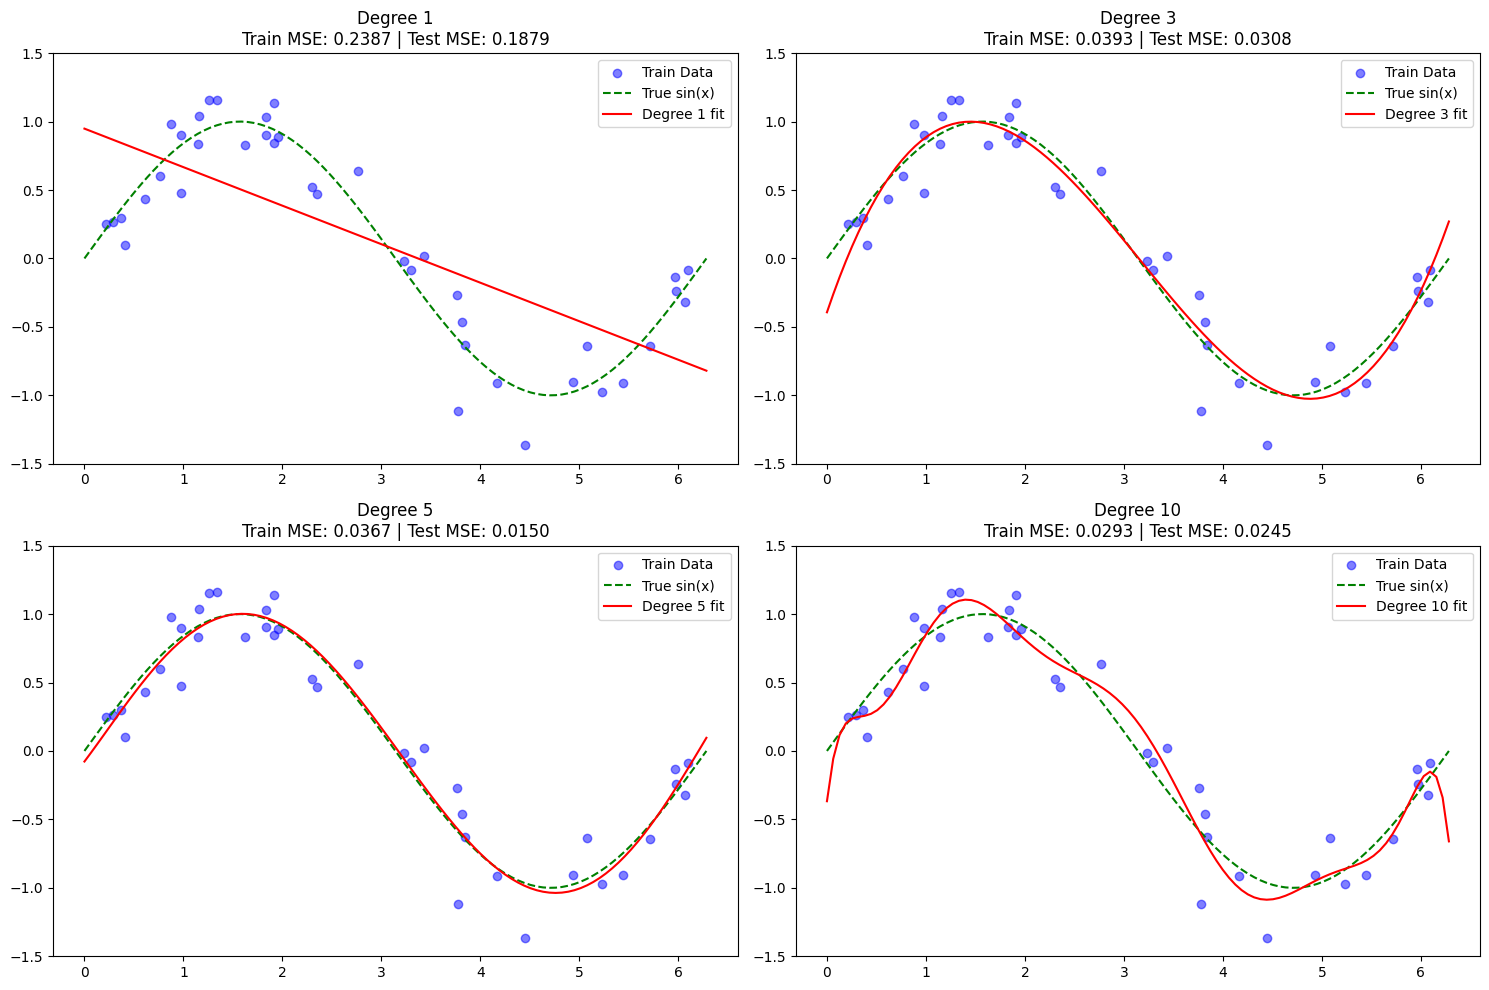

In [ ]:
n_samples = 50
sigma = 0.2

# Generate Data
x = np.sort(np.random.uniform(0, 2 * np.pi, n_samples))
y_true = np.sin(x)
y_noisy = y_true + np.random.normal(0, sigma, n_samples)

# Train-Test Split (80/20)
indices = np.random.permutation(n_samples)
train_idx, test_idx = indices[:40], indices[40:]
x_train, y_train = x[train_idx], y_noisy[train_idx]
x_test, y_test = x[test_idx], y_noisy[test_idx]

def fit_polynomial(x_vals, y_vals, degree):
    # Construct Vandermonde Matrix
    X = np.vander(x_vals, degree + 1, increasing=True)
    # Solve Normal Equation: w = (X^T X)^-1 X^T y
    w = np.linalg.inv(X.T @ X) @ (X.T @ y_vals)
    return w

def predict(x_vals, w):
    X = np.vander(x_vals, len(w), increasing=True)
    return X @ w

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# --- Visualization and Analysis ---
degrees = [1, 3, 5, 10]
plt.figure(figsize=(15, 10))
x_range = np.linspace(0, 2 * np.pi, 100)

for i, d in enumerate(degrees):
    # Train
    w = fit_polynomial(x_train, y_train, d)
    
    # Evaluate
    train_pred = predict(x_train, w)
    test_pred = predict(x_test, w)
    y_plot = predict(x_range, w)
    
    train_err = mse(y_train, train_pred)
    test_err = mse(y_test, test_pred)
    
    # Plotting
    plt.subplot(2, 2, i+1)
    plt.scatter(x_train, y_train, color='blue', alpha=0.5, label='Train Data')
    plt.plot(x_range, np.sin(x_range), 'g--', label='True sin(x)')
    plt.plot(x_range, y_plot, 'r', label=f'Degree {d} fit')
    plt.title(f'Degree {d}\nTrain MSE: {train_err:.4f} | Test MSE: {test_err:.4f}')
    plt.ylim(-1.5, 1.5)
    plt.legend()

plt.tight_layout()
plt.show()


### Solution 11

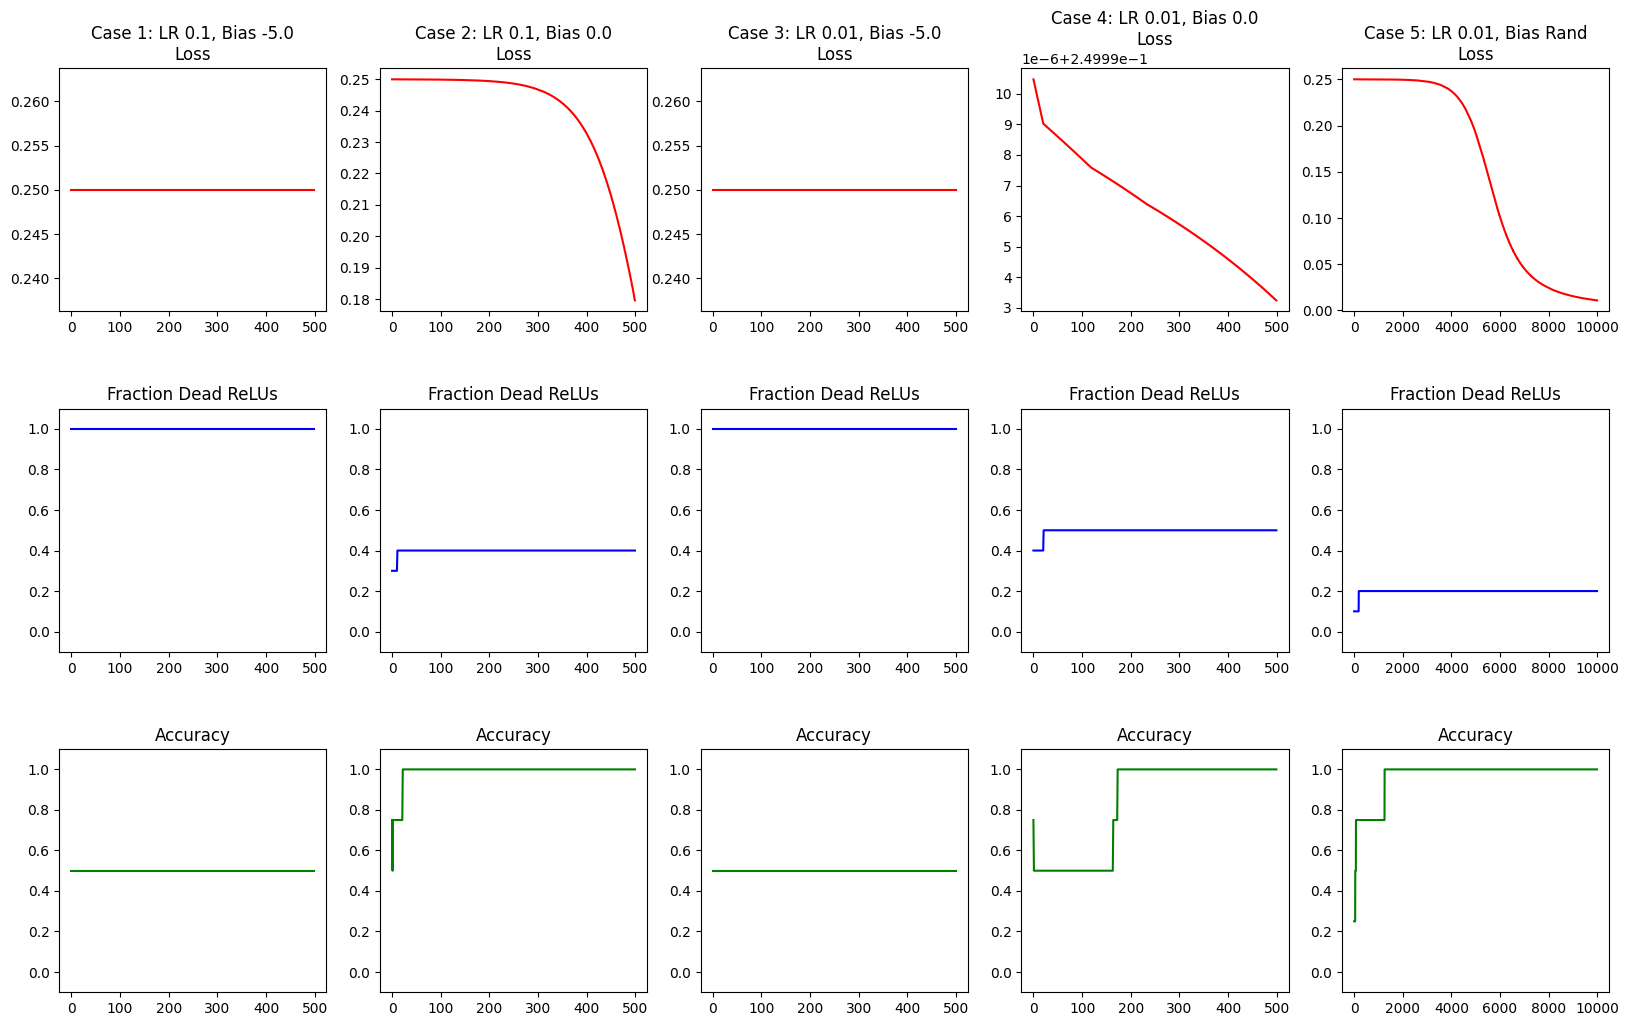

In [10]:
# XOR Data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def train_network(lr, bias_init, epochs, hidden_size=10):
    # Weight Initialization
    W1 = np.random.normal(0, 0.01, (2, hidden_size))
    W2 = np.random.normal(0, 0.01, (hidden_size, 1))
    
    # Bias Initialization
    if isinstance(bias_init, float):
        b1 = np.full((1, hidden_size), bias_init)
    else: # random
        b1 = np.random.normal(0, 0.01, (1, hidden_size))
    b2 = np.zeros((1, 1))

    history = {'loss': [], 'dead_relu': [], 'accuracy': []}

    for epoch in range(epochs):
        # Forward Pass
        z1 = np.dot(X, W1) + b1
        a1 = relu(z1)
        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        # Loss (MSE)
        loss = np.mean((a2 - y)**2)
        
        # Tracking Dead ReLUs: A neuron is dead if it outputs 0 for all training samples
        dead_count = np.sum(np.all(a1 <= 0, axis=0))
        dead_fraction = dead_count / hidden_size
        
        # Accuracy
        predictions = (a2 > 0.5).astype(int)
        accuracy = np.mean(predictions == y)

        history['loss'].append(loss)
        history['dead_relu'].append(dead_fraction)
        history['accuracy'].append(accuracy)

        # Backward Pass
        dz2 = (a2 - y) * sigmoid_derivative(z2)
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = np.dot(dz2, W2.T)
        dz1 = da1 * relu_derivative(z1)
        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update Weights
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return history

# Configurations
cases = [
    (0.1, -5.0, 500, "Case 1: LR 0.1, Bias -5.0"),
    (0.1, 0.0, 500, "Case 2: LR 0.1, Bias 0.0"),
    (0.01, -5.0, 500, "Case 3: LR 0.01, Bias -5.0"),
    (0.01, 0.0, 500, "Case 4: LR 0.01, Bias 0.0"),
    (0.01, "random", 10000, "Case 5: LR 0.01, Bias Rand")
]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
plt.subplots_adjust(hspace=0.4)

for i, (lr, b_init, ep, title) in enumerate(cases):
    hist = train_network(lr, b_init, ep)
    
    axes[0, i].plot(hist['loss'], color='red')
    axes[0, i].set_title(title + "\nLoss")
    axes[1, i].plot(hist['dead_relu'], color='blue')
    axes[1, i].set_ylim([-0.1, 1.1])
    axes[1, i].set_title("Fraction Dead ReLUs")
    axes[2, i].plot(hist['accuracy'], color='green')
    axes[2, i].set_ylim([-0.1, 1.1])
    axes[2, i].set_title("Accuracy")
